# Turn 2D pose estimation into 3D

In [2]:
from mpl_toolkits.mplot3d import Axes3D
from pose_3d_projector import Pose3DProjector
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Set up notebook to display plots inline
%matplotlib inline

print("✓ Imports successful!")

✓ Imports successful!


## Setup file paths

The toml file was made using the freemocap software suite

In [9]:
# Path to your camera calibration TOML file
# This file contains the camera intrinsics and extrinsics
CALIBRATION_FILE = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/2026-02-06_14-54-43_camera_calibration.toml"

# Path to the 2D keypoint data (output from previous step)
# This is the data_2d folder created by the MediaPipe processor
KEYPOINTS_2D_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d"

# Path where you want to save the 3D outputs
OUTPUT_3D_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d"

# Path for visualizations
VISUALIZATION_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations"

print(f"Calibration file: {CALIBRATION_FILE}")
print(f"2D keypoints directory: {KEYPOINTS_2D_DIR}")
print(f"3D output directory: {OUTPUT_3D_DIR}")

# Verify files exist
calib_path = Path(CALIBRATION_FILE)
keypoints_path = Path(KEYPOINTS_2D_DIR)

if calib_path.exists():
    print("✓ Calibration file found")
else:
    print("✗ ERROR: Calibration file not found!")

if keypoints_path.exists():
    npy_files = list(keypoints_path.glob("*_keypoints.npy"))
    print(f"✓ Found {len(npy_files)} camera keypoint files")
    for f in npy_files:
        print(f"  - {f.name}")
else:
    print("✗ ERROR: 2D keypoints directory not found!")

# Create output directories
Path(OUTPUT_3D_DIR).mkdir(parents=True, exist_ok=True)
Path(VISUALIZATION_DIR).mkdir(parents=True, exist_ok=True)
print("✓ Output directories ready")

Calibration file: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/2026-02-06_14-54-43_camera_calibration.toml
2D keypoints directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/mediapipe_output/data_2d
3D output directory: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d
✓ Calibration file found
✓ Found 3 camera keypoint files
  - camera_2_synchronized_keypoints.npy
  - camera_0_synchronized_keypoints.npy
  - camera_1_synchronized_keypoints.npy
✓ Output directories ready


## Initialsie the 3D projector

In [10]:
projector = Pose3DProjector(
    calibration_path=CALIBRATION_FILE,
    keypoints_dir=KEYPOINTS_2D_DIR,
    
    # Minimum number of cameras that must see a keypoint to triangulate it
    # 2 = minimum for triangulation
    # 3+ = more robust, better accuracy
    min_cameras_for_triangulation=2,
    
    # Minimum confidence threshold for using a 2D detection
    # Higher = stricter (only use high-confidence detections)
    # Lower = more permissive (use more detections but might include noise)
    confidence_threshold=0.3
)

print("\n✓ 3D Projector initialized!")
print(f"  - Cameras loaded: {len(projector.cameras)}")
print(f"  - Camera names: {list(projector.cameras.keys())}")
print(f"  - Min cameras required: 2")
print(f"  - Confidence threshold: 0.3")

2026-02-09 13:50:28,617 - INFO - Loaded calibration for 3 cameras
2026-02-09 13:50:28,620 - INFO - Loaded camera_2_synchronized: shape (1802, 33, 3)
2026-02-09 13:50:28,621 - INFO - Loaded camera_0_synchronized: shape (1802, 33, 3)
2026-02-09 13:50:28,621 - INFO - Loaded camera_1_synchronized: shape (1802, 33, 3)
2026-02-09 13:50:28,622 - INFO - Loaded 2D keypoints from 3 cameras



✓ 3D Projector initialized!
  - Cameras loaded: 3
  - Camera names: ['camera_0_synchronized', 'camera_1_synchronized', 'camera_2_synchronized']
  - Min cameras required: 2
  - Confidence threshold: 0.3


## Triangulate

In [11]:
# This performs Direct Linear Transform (DLT) triangulation on every frame

print("\n" + "="*70)
print("Starting 3D triangulation...")
print("="*70)

# This will triangulate all keypoints for all frames
# You'll see a progress bar
points_3d, metrics = projector.triangulate_all_frames()

print("\n✓ Triangulation complete!")
print(f"  - 3D points shape: {points_3d.shape}")
print(f"  - Format: (n_frames, n_keypoints, 3) where last dim is [x, y, z] in mm")


2026-02-09 13:50:31,450 - INFO - Triangulating frames 0 to 1802



Starting 3D triangulation...


Triangulating: 100%|██████████| 1802/1802 [00:01<00:00, 950.78it/s]
2026-02-09 13:50:33,352 - INFO - Triangulation complete!



✓ Triangulation complete!
  - 3D points shape: (1802, 33, 3)
  - Format: (n_frames, n_keypoints, 3) where last dim is [x, y, z] in mm


In [12]:
print("\n" + "="*70)
print("3D PROJECTION QUALITY METRICS")
print("="*70)

print(f"\nFrames processed:              {metrics.n_frames}")
print(f"Keypoints per frame:           {metrics.n_keypoints}")
print(f"Cameras used:                  {metrics.n_cameras}")

print(f"\nReprojection Errors (pixels):")
print(f"  Mean:                        {metrics.mean_reprojection_error:.4f}")
print(f"  Median:                      {metrics.median_reprojection_error:.4f}")
print(f"  Std Dev:                     {metrics.std_reprojection_error:.4f}")
print(f"  Max:                         {metrics.max_reprojection_error:.4f}")

print(f"\nReconstruction Quality:")
print(f"  Frames with good recon:      {metrics.frames_with_good_reconstruction}")
print(f"  Good reconstruction rate:    {metrics.frames_with_good_reconstruction/metrics.n_frames*100:.2f}%")
print(f"  Threshold used:              {metrics.good_reconstruction_threshold:.2f} pixels")

# Quality assessment
if metrics.mean_reprojection_error < 5:
    print("\n✓ EXCELLENT quality - Mean error < 5 pixels")
elif metrics.mean_reprojection_error < 10:
    print("\n✓ GOOD quality - Mean error < 10 pixels")
else:
    print("\n⚠ WARNING - High reprojection error. Check calibration and synchronization.")


3D PROJECTION QUALITY METRICS

Frames processed:              1802
Keypoints per frame:           33
Cameras used:                  3

Reprojection Errors (pixels):
  Mean:                        6.1353
  Median:                      5.0343
  Std Dev:                     4.6638
  Max:                         51.5932

Reconstruction Quality:
  Frames with good recon:      1761
  Good reconstruction rate:    97.72%
  Threshold used:              10.00 pixels

✓ GOOD quality - Mean error < 10 pixels


In [13]:
print("\n" + "="*70)
print("Saving 3D data...")
print("="*70)

# Save the 3D points
projector.save_3d_data(
    points_3d,
    output_path=str(Path(OUTPUT_3D_DIR) / "pose_3d"),
    metadata={
        'processing_date': '2026-02-06',
        'recording_session': '2026-02-06_15-06-02',
        'min_cameras': 2,
        'confidence_threshold': 0.3
    }
)

# Save the metrics
projector.save_metrics(
    metrics,
    output_path=str(Path(OUTPUT_3D_DIR) / "projection_metrics.txt")
)

print("✓ 3D data saved!")

2026-02-09 13:50:39,624 - INFO - Saved 3D points to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.npy
2026-02-09 13:50:39,626 - INFO - Saved metadata to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.json
2026-02-09 13:50:39,628 - INFO - Saved metrics to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/projection_metrics.txt



Saving 3D data...
✓ 3D data saved!


## Visualize reprojection errors

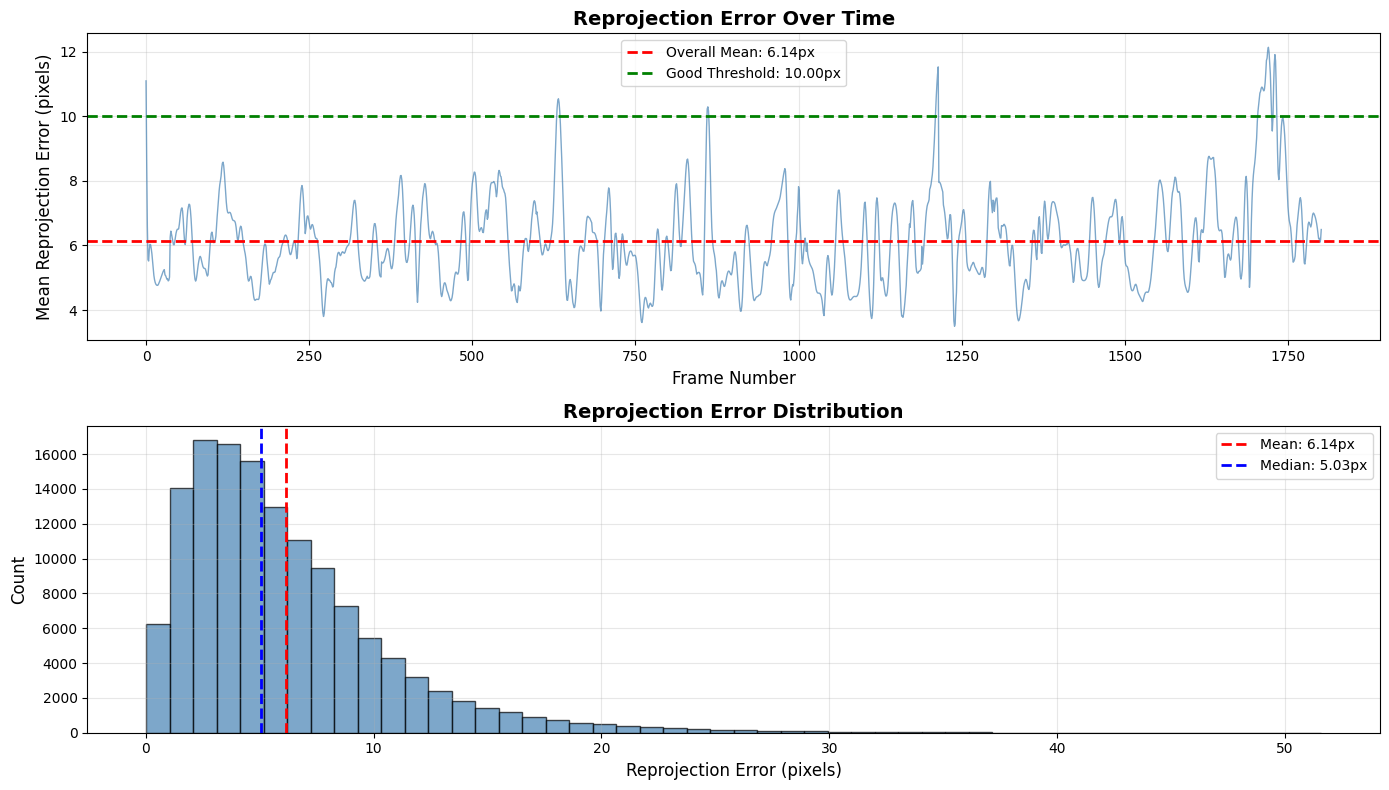

✓ Reprojection error plot saved to: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/reprojection_errors.png


In [14]:
# Compute mean error per frame
mean_errors_per_frame = np.nanmean(metrics.reprojection_errors, axis=(1, 2))

# Create figure
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Error over time
axes[0].plot(mean_errors_per_frame, linewidth=1, alpha=0.7, color='steelblue')
axes[0].axhline(
    metrics.mean_reprojection_error, 
    color='red', 
    linestyle='--', 
    label=f'Overall Mean: {metrics.mean_reprojection_error:.2f}px',
    linewidth=2
)
axes[0].axhline(
    metrics.good_reconstruction_threshold, 
    color='green', 
    linestyle='--', 
    label=f'Good Threshold: {metrics.good_reconstruction_threshold:.2f}px',
    linewidth=2
)
axes[0].set_xlabel('Frame Number', fontsize=12)
axes[0].set_ylabel('Mean Reprojection Error (pixels)', fontsize=12)
axes[0].set_title('Reprojection Error Over Time', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Error distribution histogram
valid_errors = metrics.reprojection_errors[~np.isnan(metrics.reprojection_errors)].flatten()
axes[1].hist(valid_errors, bins=50, alpha=0.7, edgecolor='black', color='steelblue')
axes[1].axvline(
    metrics.mean_reprojection_error, 
    color='red', 
    linestyle='--', 
    label=f'Mean: {metrics.mean_reprojection_error:.2f}px',
    linewidth=2
)
axes[1].axvline(
    metrics.median_reprojection_error, 
    color='blue', 
    linestyle='--', 
    label=f'Median: {metrics.median_reprojection_error:.2f}px',
    linewidth=2
)
axes[1].set_xlabel('Reprojection Error (pixels)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('Reprojection Error Distribution', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
error_plot_path = Path(VISUALIZATION_DIR) / "reprojection_errors.png"
plt.savefig(error_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Reprojection error plot saved to: {error_plot_path}")

## Quick visualisation

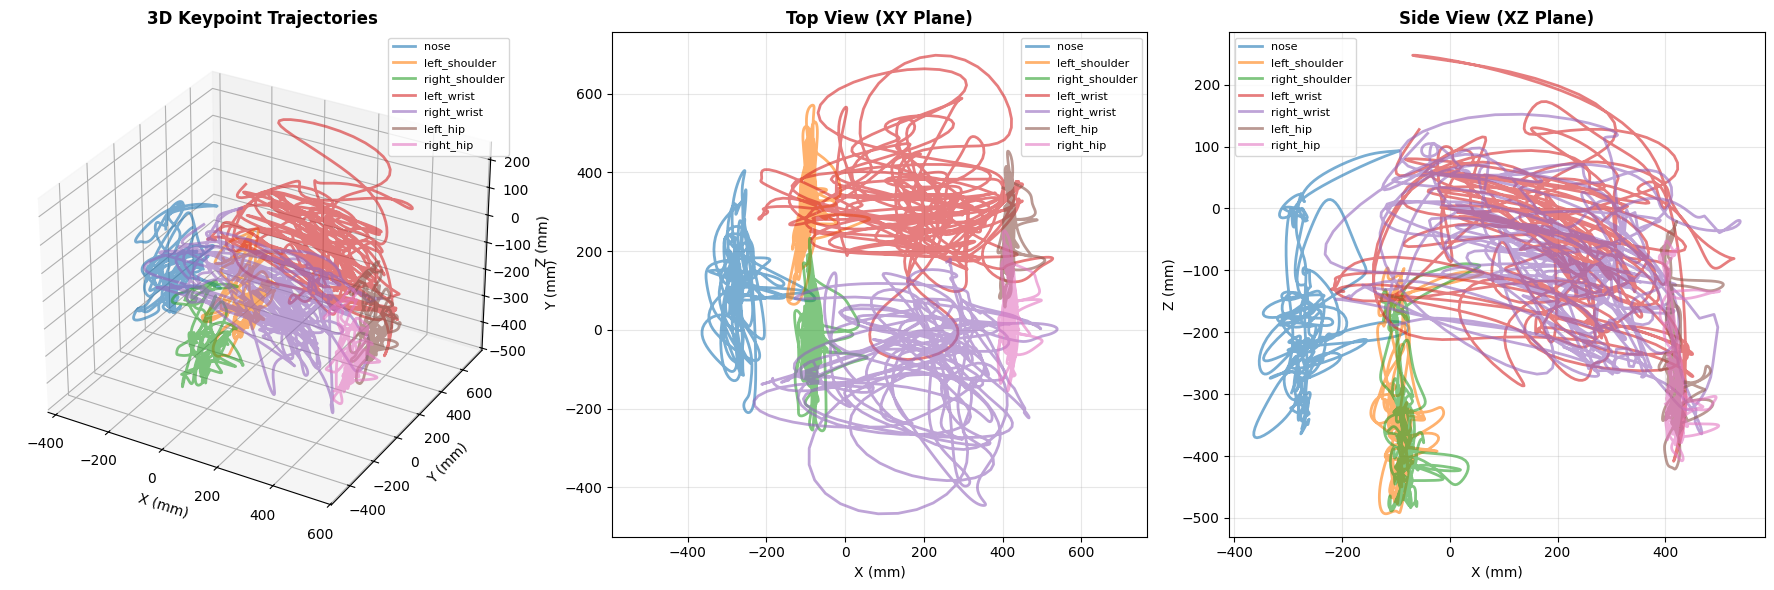

✓ 3D trajectory plot saved to: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/3d_trajectories.png


In [15]:
# Plot the 3D movement of key body points

# Select key keypoints to visualize (you can change these)
key_keypoints = {
    0: 'nose',
    11: 'left_shoulder',
    12: 'right_shoulder',
    15: 'left_wrist',
    16: 'right_wrist',
    23: 'left_hip',
    24: 'right_hip'
}

fig = plt.figure(figsize=(18, 6))

# Plot 1: 3D trajectory
ax1 = fig.add_subplot(131, projection='3d')

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax1.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax1.set_xlabel('X (mm)', fontsize=10)
ax1.set_ylabel('Y (mm)', fontsize=10)
ax1.set_zlabel('Z (mm)', fontsize=10)
ax1.set_title('3D Keypoint Trajectories', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8, loc='upper right')

# Plot 2: Top view (XY plane)
ax2 = fig.add_subplot(132)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax2.plot(
            trajectory[valid, 0],
            trajectory[valid, 1],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax2.set_xlabel('X (mm)', fontsize=10)
ax2.set_ylabel('Y (mm)', fontsize=10)
ax2.set_title('Top View (XY Plane)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=8)
ax2.axis('equal')

# Plot 3: Side view (XZ plane)
ax3 = fig.add_subplot(133)

for idx, name in key_keypoints.items():
    trajectory = points_3d[:, idx, :]
    valid = ~np.isnan(trajectory).any(axis=1)
    
    if np.sum(valid) > 0:
        ax3.plot(
            trajectory[valid, 0],
            trajectory[valid, 2],
            alpha=0.6,
            label=name,
            linewidth=2
        )

ax3.set_xlabel('X (mm)', fontsize=10)
ax3.set_ylabel('Z (mm)', fontsize=10)
ax3.set_title('Side View (XZ Plane)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=8)

plt.tight_layout()
trajectory_plot_path = Path(VISUALIZATION_DIR) / "3d_trajectories.png"
plt.savefig(trajectory_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ 3D trajectory plot saved to: {trajectory_plot_path}")



## Some simple kinematic analysis

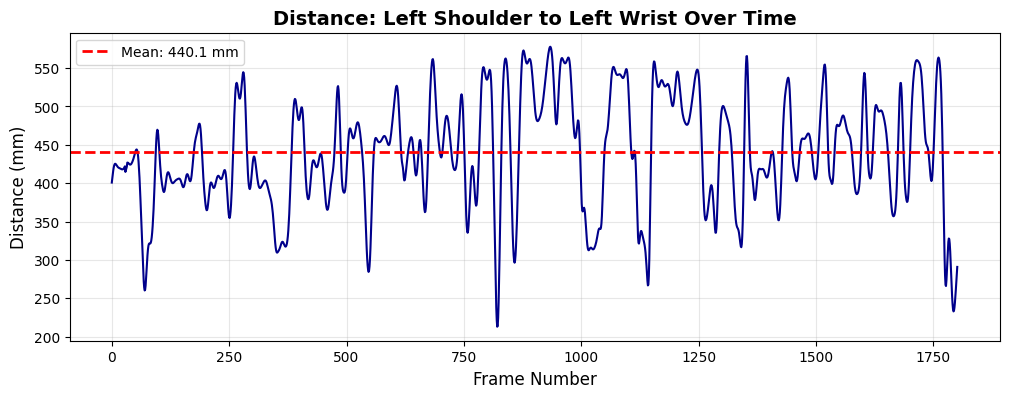


✓ Distance plot saved to: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/shoulder_wrist_distance.png
  Mean distance: 440.07 mm
  Std deviation: 72.07 mm


In [16]:
# Example: Calculate distance between two keypoints over time

from scipy.spatial.distance import euclidean

# Calculate distance from left shoulder to left wrist over all frames
left_shoulder_idx = 11
left_wrist_idx = 15

distances = []
for frame in range(points_3d.shape[0]):
    shoulder = points_3d[frame, left_shoulder_idx, :]
    wrist = points_3d[frame, left_wrist_idx, :]
    
    # Only calculate if both points are valid (not NaN)
    if not np.any(np.isnan(shoulder)) and not np.any(np.isnan(wrist)):
        dist = euclidean(shoulder, wrist)
        distances.append(dist)
    else:
        distances.append(np.nan)

distances = np.array(distances)

# Plot the distance over time
plt.figure(figsize=(12, 4))
plt.plot(distances, linewidth=1.5, color='darkblue')
plt.xlabel('Frame Number', fontsize=12)
plt.ylabel('Distance (mm)', fontsize=12)
plt.title('Distance: Left Shoulder to Left Wrist Over Time', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics
valid_distances = distances[~np.isnan(distances)]
plt.axhline(np.mean(valid_distances), color='red', linestyle='--', 
            label=f'Mean: {np.mean(valid_distances):.1f} mm', linewidth=2)
plt.legend()

distance_plot_path = Path(VISUALIZATION_DIR) / "shoulder_wrist_distance.png"
plt.savefig(distance_plot_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Distance plot saved to: {distance_plot_path}")
print(f"  Mean distance: {np.mean(valid_distances):.2f} mm")
print(f"  Std deviation: {np.std(valid_distances):.2f} mm")


## Summary of Outputs

In [18]:
print("\n" + "="*70)
print("OUTPUT FILES CREATED")
print("="*70)

print(f"\n3D Pose Data:")
print(f"  {Path(OUTPUT_3D_DIR) / 'pose_3d.npy'}")
print(f"  {Path(OUTPUT_3D_DIR) / 'pose_3d.json'}")

print(f"\nQuality Metrics:")
print(f"  {Path(OUTPUT_3D_DIR) / 'projection_metrics.txt'}")

print(f"\nVisualizations:")
print(f"  {Path(VISUALIZATION_DIR) / 'reprojection_errors.png'}")
print(f"  {Path(VISUALIZATION_DIR) / '3d_trajectories.png'}")
print(f"  {Path(VISUALIZATION_DIR) / 'shoulder_wrist_distance.png'}")



OUTPUT FILES CREATED

3D Pose Data:
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.npy
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.json

Quality Metrics:
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/projection_metrics.txt

Visualizations:
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/reprojection_errors.png
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/3d_trajectories.png
  /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/visualizations/shoulder_wrist_distance.png


## Make a 3D video of the movements over time

In [3]:
from pose_animator import (
    detect_person_orientation, 
    get_optimal_camera_angles,
    visualize_orientation,
    animate_3d_pose,
    animate_3d_pose_multiangle
)

%matplotlib inline

In [4]:
POSE_3D_FILE = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/data_3d/pose_3d.npy"
OUTPUT_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02"

points_3d = np.load(POSE_3D_FILE)
print(f"✓ Loaded 3D data: {points_3d.shape}")

✓ Loaded 3D data: (1802, 33, 3)


In [5]:
print("\n" + "="*70)
print("Detecting person orientation")
print("="*70)

# Detect orientation (uses median across frames for robustness)
orientation = detect_person_orientation(points_3d)

# Print whatever keys are actually in the orientation dict
print(f"\n✓ Detected orientation:")
print(f"  Orientation data: {orientation}")



Detecting person orientation

DETECTING PERSON ORIENTATION

✓ UP direction detected: [-0.989, 0.020, -0.145]
  Dominant axis: X
✓ FORWARD direction detected: [-0.147, -0.089, 0.985]
✓ RIGHT direction detected: [-0.007, -0.996, -0.091]
✓ Ground plane detected at: 0.00 mm along up-axis

✓ Orientation detection complete!

✓ Detected orientation:
  Orientation data: {'up_vector': array([-0.98915849,  0.02011921, -0.14546718]), 'forward_vector': array([-0.14668873, -0.08868336,  0.98519931]), 'right_vector': array([-0.00692092, -0.99585666, -0.09067316]), 'rotation_matrix': array([[-0.00692092, -0.14668873, -0.98915849],
       [-0.99585666, -0.08868336,  0.02011921],
       [-0.09067316,  0.98519931, -0.14546718]]), 'ground_plane_z': 0, 'up_axis': 0, 'forward_axis': 2}


In [6]:
# ============================================================================
# Deterministic viewing angle calculation
# ============================================================================

def calculate_view_angles_deterministic(orientation):
    """
    Calculate matplotlib viewing angles based on which world axes
    the person's orientation vectors align with.
    
    Strategy: Detect which axis each orientation vector points along,
    then set view angles accordingly.
    """
    
    up = orientation.get('up_vector', np.array([0, 0, 1]))
    forward = orientation.get('forward_vector', np.array([1, 0, 0]))
    right = orientation.get('right_vector', np.array([0, 1, 0]))
    
    print("="*70)
    print("DETERMINISTIC VIEW ANGLE CALCULATION")
    print("="*70)
    
    # Find which axis each orientation vector aligns with
    def get_dominant_axis(vec):
        """Return (axis_index, sign) for dominant component."""
        abs_vec = np.abs(vec)
        axis = np.argmax(abs_vec)  # 0=X, 1=Y, 2=Z
        sign = np.sign(vec[axis])
        return axis, sign, abs_vec[axis]
    
    up_axis, up_sign, up_mag = get_dominant_axis(up)
    fwd_axis, fwd_sign, fwd_mag = get_dominant_axis(forward)
    right_axis, right_sign, right_mag = get_dominant_axis(right)
    
    axis_names = ['X', 'Y', 'Z']
    
    print(f"\nOrientation alignment:")
    print(f"  UP      → {'+' if up_sign > 0 else '-'}{axis_names[up_axis]} (magnitude: {up_mag:.3f})")
    print(f"  FORWARD → {'+' if fwd_sign > 0 else '-'}{axis_names[fwd_axis]} (magnitude: {fwd_mag:.3f})")
    print(f"  RIGHT   → {'+' if right_sign > 0 else '-'}{axis_names[right_axis]} (magnitude: {right_mag:.3f})")
    
    # Determine view angles based on forward direction
    # We want to look FROM the opposite direction of forward
    
    if fwd_axis == 2:  # Forward is along Z
        # Look down/up the Z axis
        elev = 90 * fwd_sign  # +90 if forward=+Z, -90 if forward=-Z
        azim = 0  # Default azimuth
        
    elif fwd_axis == 0:  # Forward is along X
        # Look along X axis
        elev = 0
        azim = 0 if fwd_sign > 0 else 180
        
    elif fwd_axis == 1:  # Forward is along Y
        # Look along Y axis
        elev = 0
        azim = 90 if fwd_sign > 0 else -90
    
    print(f"\nCalculated viewing angles:")
    print(f"  Elevation: {elev:.1f}°")
    print(f"  Azimuth:   {azim:.1f}°")
    
    return {'elev': elev, 'azim': azim}


# ============================================================================
# Calculate angles
# ============================================================================

calc_angles = calculate_view_angles_deterministic(orientation)

print("\n" + "="*70)
print("RESULT")
print("="*70)
print(f"\nManually found: elev=90°, azim=0°")
print(f"Calculated:     elev={calc_angles['elev']:.1f}°, azim={calc_angles['azim']:.1f}°")
print(f"\n✓ Match: {calc_angles['elev'] == 90 and calc_angles['azim'] == 0}")

DETERMINISTIC VIEW ANGLE CALCULATION

Orientation alignment:
  UP      → -X (magnitude: 0.989)
  FORWARD → +Z (magnitude: 0.985)
  RIGHT   → -Y (magnitude: 0.996)

Calculated viewing angles:
  Elevation: 90.0°
  Azimuth:   0.0°

RESULT

Manually found: elev=90°, azim=0°
Calculated:     elev=90.0°, azim=0.0°

✓ Match: True


In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from pathlib import Path

# Use interactive backend (Qt)
%matplotlib qt

# ============================================================================
# Align to standard anatomical frame
# ============================================================================

def align_pose_to_standard_frame(points_3d, orientation):
    """
    Rotate 3D pose data to a standard anatomical coordinate frame.
    
    Standard frame (biomechanics convention):
    - X-axis: Medial-Lateral (person's right → +X)
    - Y-axis: Anterior-Posterior (person's forward → +Y) 
    - Z-axis: Superior-Inferior (person's up → +Z)
    """
    
    # Get orientation vectors
    up = orientation.get('up_vector', np.array([0, 0, 1]))
    forward = orientation.get('forward_vector', np.array([1, 0, 0]))
    right = orientation.get('right_vector', np.array([0, 1, 0]))
    
    # Normalize
    up = up / np.linalg.norm(up)
    forward = forward / np.linalg.norm(forward)
    right = right / np.linalg.norm(right)
    
    print("="*70)
    print("ALIGNING TO STANDARD ANATOMICAL FRAME")
    print("="*70)
    print(f"\nDetected orientation (world frame):")
    print(f"  UP:      {up}")
    print(f"  FORWARD: {forward}")
    print(f"  RIGHT:   {right}")
    
    # Build rotation matrix to map to standard frame:
    # Person's RIGHT → +X (medial-lateral)
    # Person's FORWARD → +Y (anterior-posterior)
    # Person's UP → +Z (superior-inferior)
    
    rotation_matrix = np.array([
        right,    # Maps to new X-axis
        forward,  # Maps to new Y-axis  
        up        # Maps to new Z-axis
    ])
    
    print(f"\nRotation matrix:")
    print(rotation_matrix)
    
    # Apply rotation to all points
    rotated = np.zeros_like(points_3d)
    
    if points_3d.ndim == 3:
        # Shape: (n_frames, n_keypoints, 3)
        for frame_idx in range(points_3d.shape[0]):
            for kp_idx in range(points_3d.shape[1]):
                point = points_3d[frame_idx, kp_idx]
                if not np.any(np.isnan(point)):
                    rotated[frame_idx, kp_idx] = rotation_matrix @ point
                else:
                    rotated[frame_idx, kp_idx] = point  # Preserve NaN
    
    elif points_3d.ndim == 2:
        # Shape: (n_keypoints, 3)
        for kp_idx in range(points_3d.shape[0]):
            point = points_3d[kp_idx]
            if not np.any(np.isnan(point)):
                rotated[kp_idx] = rotation_matrix @ point
            else:
                rotated[kp_idx] = point
    
    # Verify rotation
    print(f"\nVerification (orientation in new frame):")
    up_new = rotation_matrix @ up
    forward_new = rotation_matrix @ forward
    right_new = rotation_matrix @ right
    print(f"  UP      → {up_new} (should be [0, 0, 1])")
    print(f"  FORWARD → {forward_new} (should be [0, 1, 0])")
    print(f"  RIGHT   → {right_new} (should be [1, 0, 0])")
    
    print(f"\n✓ Data rotated to standard anatomical frame")
    print(f"  Standard viewing angles:")
    print(f"    Front: elev=0°, azim=90°  (camera on +Y looking at front)")
    print(f"    Right: elev=0°, azim=0°   (camera on +X looking at right side)")
    print(f"    Back:  elev=0°, azim=-90° (camera on -Y looking at back)")
    print(f"    Top:   elev=90°, azim=0°  (camera above looking down)")
    
    return rotated, rotation_matrix

# Align data to standard frame
points_3d_aligned, R = align_pose_to_standard_frame(points_3d, orientation)

# ============================================================================
# Interactive plot with aligned data
# ============================================================================

print("\n" + "="*70)
print("INTERACTIVE 3D POSE VIEWER - ALIGNED FRAME")
print("="*70)

# Select frame to visualize
frame_idx = points_3d_aligned.shape[0] // 2  # Middle frame
frame = points_3d_aligned[frame_idx]

print(f"\nViewing frame {frame_idx}")
print("Data is now in standard anatomical frame!")
print("  X = Right (+) / Left (-)")
print("  Y = Forward (+) / Back (-)")
print("  Z = Up (+) / Down (-)")

# ============================================================================
# Calculate axis limits
# ============================================================================

valid_mask = ~np.isnan(frame).any(axis=1)
valid_points = frame[valid_mask]

if len(valid_points) == 0:
    print("ERROR: No valid points in this frame!")
else:
    # Calculate ranges
    x_min, x_max = valid_points[:, 0].min(), valid_points[:, 0].max()
    y_min, y_max = valid_points[:, 1].min(), valid_points[:, 1].max()
    z_min, z_max = valid_points[:, 2].min(), valid_points[:, 2].max()
    
    print(f"\nCoordinate ranges (aligned frame):")
    print(f"  X (R/L): {x_min:.2f} to {x_max:.2f}")
    print(f"  Y (F/B): {y_min:.2f} to {y_max:.2f}")
    print(f"  Z (U/D): {z_min:.2f} to {z_max:.2f}")
    
    # Add padding (20%)
    x_range = x_max - x_min
    y_range = y_max - y_min
    z_range = z_max - z_min
    
    padding = 0.2
    x_limits = [x_min - x_range*padding, x_max + x_range*padding]
    y_limits = [y_min - y_range*padding, y_max + y_range*padding]
    z_limits = [z_min - z_range*padding, z_max + z_range*padding]

# ============================================================================
# Create the plot
# ============================================================================

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# MediaPipe skeleton connections
connections = [
    # Face
    (0, 1), (1, 2), (2, 3), (3, 7),
    (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    # Torso
    (11, 12), (11, 23), (12, 24), (23, 24),
    # Left arm
    (11, 13), (13, 15), (15, 17), (15, 19), (15, 21),
    # Right arm
    (12, 14), (14, 16), (16, 18), (16, 20), (16, 22),
    # Left leg
    (23, 25), (25, 27), (27, 29), (27, 31),
    # Right leg
    (24, 26), (26, 28), (28, 30), (28, 32),
]

def get_connection_color(connection):
    """Assign colors to skeleton connections."""
    start, end = connection
    if start <= 10 and end <= 10:
        return '#FF6B6B'  # Red - Face
    if connection in [(11, 12), (11, 23), (12, 24), (23, 24)]:
        return '#4ECDC4'  # Teal - Torso
    if start in [11, 13, 15, 17, 19, 21] and end in [11, 13, 15, 17, 19, 21]:
        return '#45B7D1'  # Blue - Left arm
    if start in [12, 14, 16, 18, 20, 22] and end in [12, 14, 16, 18, 20, 22]:
        return '#96CEB4'  # Green - Right arm
    if start in [23, 25, 27, 29, 31] and end in [23, 25, 27, 29, 31]:
        return '#FFEAA7'  # Yellow - Left leg
    if start in [24, 26, 28, 30, 32] and end in [24, 26, 28, 30, 32]:
        return '#DDA15E'  # Orange - Right leg
    return '#888888'

# Plot skeleton connections
for connection in connections:
    start_idx, end_idx = connection
    start_point = frame[start_idx]
    end_point = frame[end_idx]
    
    if not np.any(np.isnan(start_point)) and not np.any(np.isnan(end_point)):
        color = get_connection_color(connection)
        ax.plot3D(
            [start_point[0], end_point[0]],
            [start_point[1], end_point[1]],
            [start_point[2], end_point[2]],
            color=color,
            linewidth=3,
            alpha=0.8
        )

# Plot keypoints
ax.scatter(
    valid_points[:, 0],
    valid_points[:, 1],
    valid_points[:, 2],
    c='#2C3E50',
    s=100,
    alpha=0.9,
    edgecolors='white',
    linewidths=2,
    depthshade=True
)

# ============================================================================
# Calculate body center for axes
# ============================================================================

mid_hip = (frame[23] + frame[24]) / 2
mid_shoulder = (frame[11] + frame[12]) / 2

if not np.any(np.isnan([mid_hip, mid_shoulder])):
    center = (mid_hip + mid_shoulder) / 2
else:
    center = np.mean(valid_points, axis=0)

# ============================================================================
# Plot STANDARD anatomical axes
# ============================================================================

axis_length = max(x_range, y_range, z_range) * 0.5

# X-axis (RIGHT - Red)
ax.quiver(center[0], center[1], center[2], axis_length, 0, 0,
         color='red', linewidth=5, arrow_length_ratio=0.15, alpha=0.9)
ax.text(center[0] + axis_length*1.2, center[1], center[2],
        'RIGHT (+X)', fontsize=14, color='red', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Y-axis (FORWARD - Green)
ax.quiver(center[0], center[1], center[2], 0, axis_length, 0,
         color='green', linewidth=5, arrow_length_ratio=0.15, alpha=0.9)
ax.text(center[0], center[1] + axis_length*1.2, center[2],
        'FORWARD (+Y)', fontsize=14, color='green', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Z-axis (UP - Blue)
ax.quiver(center[0], center[1], center[2], 0, 0, axis_length,
         color='blue', linewidth=5, arrow_length_ratio=0.15, alpha=0.9)
ax.text(center[0], center[1], center[2] + axis_length*1.2,
        'UP (+Z)', fontsize=14, color='blue', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ============================================================================
# Set labels, title, and axis limits
# ============================================================================

ax.set_xlabel('X (mm) - Medial/Lateral', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (mm) - Anterior/Posterior', fontsize=12, fontweight='bold')
ax.set_zlabel('Z (mm) - Superior/Inferior', fontsize=12, fontweight='bold')

ax.set_title(
    f'3D Pose - Standard Anatomical Frame (Frame {frame_idx})\n'
    f'Current: Front view (elev=0°, azim=90°)',
    fontsize=14, fontweight='bold', pad=20
)

ax.set_xlim(x_limits)
ax.set_ylim(y_limits)
ax.set_zlim(z_limits)

# Equal aspect
ax.set_box_aspect([x_range, y_range, z_range])

# Grid
ax.grid(True, alpha=0.3)

# ============================================================================
# Set STANDARD viewing angle (Front view - CORRECTED)
# ============================================================================

# Front view: camera on +Y axis, looking along -Y at person's front
ax.view_init(elev=0, azim=90)

# ============================================================================
# Legend
# ============================================================================

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#FF6B6B', label='Face'),
    Patch(facecolor='#4ECDC4', label='Torso'),
    Patch(facecolor='#45B7D1', label='Left Arm'),
    Patch(facecolor='#96CEB4', label='Right Arm'),
    Patch(facecolor='#FFEAA7', label='Left Leg'),
    Patch(facecolor='#DDA15E', label='Right Leg'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================================
# Print CORRECTED standard viewing angles
# ============================================================================

print("\n" + "="*70)
print("STANDARD VIEWING ANGLES (CORRECTED)")
print("="*70)
print(f"\nUse these angles for all datasets:")
print(f"  Front view:  elev=0°, azim=90°   (camera on +Y, looking at front)")
print(f"  Right view:  elev=0°, azim=0°    (camera on +X, looking at right side)")
print(f"  Back view:   elev=0°, azim=-90°  (camera on -Y, looking at back)")
print(f"  Left view:   elev=0°, azim=180°  (camera on -X, looking at left side)")
print(f"  Top view:    elev=90°, azim=0°   (camera above, looking down)")

print("\n" + "="*70)
print("✓ Data aligned to standard anatomical frame!")
print("="*70)

ALIGNING TO STANDARD ANATOMICAL FRAME

Detected orientation (world frame):
  UP:      [-0.98915849  0.02011921 -0.14546718]
  FORWARD: [-0.14668873 -0.08868336  0.98519931]
  RIGHT:   [-0.00692092 -0.99585666 -0.09067316]

Rotation matrix:
[[-0.00692092 -0.99585666 -0.09067316]
 [-0.14668873 -0.08868336  0.98519931]
 [-0.98915849  0.02011921 -0.14546718]]

Verification (orientation in new frame):
  UP      → [-1.17268866e-18 -2.20005476e-16  1.00000000e+00] (should be [0, 0, 1])
  FORWARD → [ 2.71661683e-17  1.00000000e+00 -2.20005476e-16] (should be [0, 1, 0])
  RIGHT   → [ 1.00000000e+00  2.71661683e-17 -1.17268866e-18] (should be [1, 0, 0])

✓ Data rotated to standard anatomical frame
  Standard viewing angles:
    Front: elev=0°, azim=90°  (camera on +Y looking at front)
    Right: elev=0°, azim=0°   (camera on +X looking at right side)
    Back:  elev=0°, azim=-90° (camera on -Y looking at back)
    Top:   elev=90°, azim=0°  (camera above looking down)

INTERACTIVE 3D POSE VIEWER 

## Create animation from the front view

In [10]:
# From the front

animate_3d_pose(
    points_3d_aligned,
    show_floor=False,
    view_mode = 'rotating',
    rotation_speed=0.5,
    rotation_axis='z',
    output_path=OUTPUT_DIR+"/animations/pose_front.mp4",
    elevation=0,
    azimuth_start=90,
    keypoint_size=70,
    line_width=4,
    show_axes=False,
    fps=30,
    quality='high'
)



CREATING 3D POSE ANIMATION

Settings:
  Total frames available: 1802
  Frames to animate: 1802
  FPS: 30
  Duration: 60.07 seconds
  View mode: rotating
  Rotation axis: Z
  Rotation speed: 0.5°/frame
  Quality: high (DPI: 150, Bitrate: 5000)
  Output: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/pose_front.mp4

Generating animation frames...
Saving video to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/pose_front.mp4...


Rendering:   0%|          | 0/1802 [00:00<?, ?it/s]2026-02-09 16:54:25,849 - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-02-09 16:54:25,850 - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1800x1192 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec libx264 -b 5000k -y /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/pose_front.mp4
Rendering: 100%|██████████| 1802/1802 [00:53<00:00, 33.51it/s]


✓ Animation saved successfully!
  File: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/pose_front.mp4
  Size: 17.41 MB
  Duration: 60.07 seconds


'/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/pose_front.mp4'

## Create an ensemble (front, left, right, top)

In [9]:
# Then: Create multi-angle animation
animate_3d_pose_multiangle(
    points_3d_aligned,  # IMPORTANT: Use aligned data!
    output_path=OUTPUT_DIR + "/animations/multiplot.mp4",
    show_floor=False,
    keypoint_size=70,
    line_width=4,
    show_axes=False,
    fps=30,
    quality='high'
)


CREATING MULTI-ANGLE 3D POSE ANIMATION

Settings:
  Total frames available: 1802
  Frames to animate: 1802
  FPS: 30
  Duration: 60.07 seconds
  View mode: Multi-angle (2x2 grid)
  Quality: high (DPI: 150, Bitrate: 5000)
  Output: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/multiplot.mp4

Generating animation frames...


Animating:   0%|          | 0/1802 [00:00<?, ?it/s]2026-02-09 16:25:18,586 - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2026-02-09 16:25:18,587 - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 2400x2400 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -b 5000k -metadata artist=pose_animator -y /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/multiplot.mp4



Saving video to /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/multiplot.mp4...


Animating: 100%|█████████▉| 1801/1802 [03:24<00:00,  7.25it/s]


✓ Multi-angle animation saved successfully!
  File: /Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/multiplot.mp4
  Size: 34.60 MB
  Duration: 60.07 seconds
  Views: Front, Right, Top, Left


'/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02/animations/multiplot.mp4'

## Combine with the original videos

In [ ]:
from pathlib import Path
import cv2
import numpy as np

def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap

def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h

def fit_with_letterbox(frame, target_w, target_h):
    """Resize preserving aspect ratio; pad with black to exactly (target_w, target_h)."""
    if frame is None:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    h, w = frame.shape[:2]
    if w == 0 or h == 0:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(w * scale))
    new_h = max(1, int(h * scale))

    resized = cv2.resize(frame, (new_w, new_h), interpolation=cv2.INTER_AREA)
    canvas = np.zeros((target_h, target_w, 3), dtype=np.uint8)

    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    canvas[y0:y0+new_h, x0:x0+new_w] = resized
    return canvas

def combine_cameras_and_multiplot(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/multiplot.mp4",
    out_name="animations/video_pose.mp4"
):
    """
    Combine synchronized camera videos with multi-angle 3D pose visualization.
    
    Layout:
    ┌─────────────┬─────────────┐
    │   Camera 0  │             │
    ├─────────────┤   Multiplot │
    │   Camera 1  │   (2x2 3D)  │
    ├─────────────┤             │
    │   Camera 2  │             │
    └─────────────┴─────────────┘
    
    Left side: 3 synchronized camera videos stacked vertically (2x1 layout)
    Right side: Multi-angle 3D pose animation (multiplot.mp4)
    
    Args:
        OUTPUT_DIR: Base output directory
        synced_folder_name: Folder containing synchronized videos
        multiplot_rel: Path to multiplot.mp4 relative to OUTPUT_DIR
        out_name: Output filename relative to OUTPUT_DIR
        
    Returns:
        str: Path to saved combined video
    """
    
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    multiplot_path = OUTPUT_DIR / multiplot_rel
    out_path = OUTPUT_DIR / out_name
    
    # Validate inputs
    if not multiplot_path.exists():
        raise FileNotFoundError(f"Missing multiplot video: {multiplot_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(f"Missing synchronized videos folder: {synced_dir}")
    
    # Get exactly 3 camera videos
    camera_paths = sorted(synced_dir.glob("camera_*_synchronized.mp4"))[:3]
    if len(camera_paths) < 3:
        raise FileNotFoundError(f"Need at least 3 camera videos in {synced_dir}, found {len(camera_paths)}")
    
    print("="*70)
    print("COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION")
    print("="*70)
    
    # Open all captures
    cap_multiplot = open_or_raise(multiplot_path)
    caps_cameras = [open_or_raise(p) for p in camera_paths]
    
    # Get video info
    fps_multi, n_multi, multi_w, multi_h = get_video_info(cap_multiplot)
    camera_infos = [get_video_info(c) for c in caps_cameras]
    
    # Use multiplot FPS as reference
    out_fps = fps_multi if fps_multi and fps_multi > 0 else 30.0
    
    print(f"\nVideo information:")
    print(f"  Multiplot: {multi_w}x{multi_h} @ {fps_multi:.2f} fps, {n_multi} frames")
    for i, (fps, n, w, h) in enumerate(camera_infos):
        print(f"  Camera {i}: {w}x{h} @ {fps:.2f} fps, {n} frames")
    
    # Sync: trim to minimum frame count across all videos
    min_frames = min(
        n_multi,
        *[info[1] for info in camera_infos]
    )
    
    if min_frames <= 0:
        raise RuntimeError("Could not determine valid frame counts (min_frames <= 0).")
    
    print(f"\nOutput settings:")
    print(f"  Synchronized frames: {min_frames}")
    print(f"  Duration: {min_frames/out_fps:.2f} seconds")
    print(f"  FPS: {out_fps:.2f}")
    
    # ========================================================================
    # Layout calculations
    # ========================================================================
    
    # Left side: Stack 3 cameras vertically
    # Make left side same height as multiplot
    left_w = multi_w  # Same width as multiplot for 50/50 split
    left_h = multi_h
    
    # Each camera cell height
    camera_cell_h = left_h // 3
    
    # Right side: Multiplot (keep original size)
    right_w = multi_w
    right_h = multi_h
    
    # Output dimensions
    out_w = left_w + right_w
    out_h = max(left_h, right_h)
    
    print(f"  Layout:")
    print(f"    Left (cameras): {left_w}x{left_h} (3 cameras stacked)")
    print(f"    Right (multiplot): {right_w}x{right_h}")
    print(f"    Output size: {out_w}x{out_h}")
    
    # ========================================================================
    # Create output video
    # ========================================================================
    
    out_path.parent.mkdir(parents=True, exist_ok=True)
    
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")
    
    print(f"\nWriting combined video...")
    
    # Process each frame
    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")
        
        # Read multiplot frame (right side)
        ok_multi, f_multi = cap_multiplot.read()
        if not ok_multi or f_multi is None:
            f_multi = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        else:
            # Ensure exact size
            if f_multi.shape[:2] != (right_h, right_w):
                f_multi = cv2.resize(f_multi, (right_w, right_h), interpolation=cv2.INTER_AREA)
        
        # Read camera frames (left side)
        camera_frames = []
        for cap in caps_cameras:
            ok, f = cap.read()
            if not ok or f is None:
                f = None
            # Fit into camera cell with letterbox
            camera_frames.append(fit_crop_fill(f, left_w, camera_cell_h))
        
        # Stack camera frames vertically
        left_side = np.vstack(camera_frames)
        
        # Ensure left side is exact height
        if left_side.shape[0] != left_h:
            left_side = cv2.resize(left_side, (left_w, left_h), interpolation=cv2.INTER_AREA)
        
        # Combine left (cameras) and right (multiplot) horizontally
        frame_out = np.hstack([left_side, f_multi])
        
        writer.write(frame_out)
    
    # Cleanup
    writer.release()
    cap_multiplot.release()
    for c in caps_cameras:
        c.release()
    
    print(f"\n✅ Combined video saved successfully!")
    print(f"  Output: {out_path}")
    print(f"  Size: {out_w}x{out_h}")
    print(f"  Frames: {min_frames}")
    print(f"  Duration: {min_frames/out_fps:.2f}s")
    
    return str(out_path)



In [14]:

result = combine_cameras_and_multiplot(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    multiplot_rel="animations/multiplot.mp4",
    out_name="animations/video_pose.mp4"
)



COMBINING CAMERA VIDEOS + MULTIPLOT 3D VISUALIZATION

Video information:
  Multiplot: 2400x2400 @ 30.00 fps, 1802 frames
  Camera 0: 1280x720 @ 30.00 fps, 1802 frames
  Camera 1: 1280x720 @ 30.00 fps, 1802 frames
  Camera 2: 1280x720 @ 30.00 fps, 1802 frames

Output settings:
  Synchronized frames: 1802
  Duration: 60.07 seconds
  FPS: 30.00
  Layout:
    Left (cameras): 2400x2400 (3 cameras stacked)
    Right (multiplot): 2400x2400
    Output size: 4800x2400

Writing combined video...
  Processing frame 0/1802...
  Processing frame 100/1802...
  Processing frame 200/1802...
  Processing frame 300/1802...
  Processing frame 400/1802...
  Processing frame 500/1802...
  Processing frame 600/1802...
  Processing frame 700/1802...
  Processing frame 800/1802...
  Processing frame 900/1802...
  Processing frame 1000/1802...
  Processing frame 1100/1802...
  Processing frame 1200/1802...
  Processing frame 1300/1802...
  Processing frame 1400/1802...
  Processing frame 1500/1802...
  Process

In [15]:
from pathlib import Path
import cv2
import numpy as np


def open_or_raise(path: Path) -> cv2.VideoCapture:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {path}")
    return cap


def get_video_info(cap: cv2.VideoCapture):
    fps = cap.get(cv2.CAP_PROP_FPS)
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    return fps, n, w, h


def resize_to_width(frame, target_w):
    """Resize to target_w preserving aspect ratio (no padding/cropping)."""
    if frame is None:
        return None
    h, w = frame.shape[:2]
    if w <= 0 or h <= 0:
        return None
    scale = target_w / w
    new_h = max(1, int(round(h * scale)))
    return cv2.resize(frame, (target_w, new_h), interpolation=cv2.INTER_AREA)


def combine_cameras_and_front_view(
    OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose.mp4",
):
    """
    Combine synchronized camera videos with front view 3D pose visualization.

    NEW LAYOUT (no letterboxing borders):
    - Left: 3 camera videos stacked vertically, each resized to the same width (keeps full frame).
    - Right: Front view resized to match the full stacked height (keeps full frame).
    - Output: [stacked cameras | front view]

    Args:
        OUTPUT_DIR: Base output directory
        synced_folder_name: Folder containing synchronized videos
        front_view_rel: Path to pose_front.mp4 relative to OUTPUT_DIR
        out_name: Output filename relative to OUTPUT_DIR

    Returns:
        str: Path to saved combined video
    """
    OUTPUT_DIR = Path(OUTPUT_DIR)
    synced_dir = OUTPUT_DIR / synced_folder_name
    front_view_path = OUTPUT_DIR / front_view_rel
    out_path = OUTPUT_DIR / out_name

    # Validate inputs
    if not front_view_path.exists():
        raise FileNotFoundError(f"Missing front view video: {front_view_path}")
    if not synced_dir.exists():
        raise FileNotFoundError(f"Missing synchronized videos folder: {synced_dir}")

    # Get exactly 3 camera videos
    camera_paths = sorted(synced_dir.glob("camera_*_synchronized.mp4"))[:3]
    if len(camera_paths) < 3:
        raise FileNotFoundError(
            f"Need at least 3 camera videos in {synced_dir}, found {len(camera_paths)}"
        )

    print("=" * 70)
    print("COMBINING CAMERA VIDEOS + FRONT VIEW 3D VISUALIZATION")
    print("=" * 70)

    # Open all captures
    cap_front = open_or_raise(front_view_path)
    caps_cameras = [open_or_raise(p) for p in camera_paths]

    # Get video info
    fps_front, n_front, front_w, front_h = get_video_info(cap_front)
    camera_infos = [get_video_info(c) for c in caps_cameras]

    # Use front view FPS as reference
    out_fps = fps_front if fps_front and fps_front > 0 else 30.0

    print(f"\nVideo information:")
    print(f"  Front view: {front_w}x{front_h} @ {fps_front:.2f} fps, {n_front} frames")
    for i, (fps, n, w, h) in enumerate(camera_infos):
        print(f"  Camera {i}: {w}x{h} @ {fps:.2f} fps, {n} frames")

    # Sync: trim to minimum frame count across all videos
    min_frames = min(n_front, *[info[1] for info in camera_infos])
    if min_frames <= 0:
        raise RuntimeError("Could not determine valid frame counts (min_frames <= 0).")

    print(f"\nOutput settings:")
    print(f"  Synchronized frames: {min_frames}")
    print(f"  Duration: {min_frames / out_fps:.2f} seconds")
    print(f"  FPS: {out_fps:.2f}")

    # ========================================================================
    # Layout calculations (NO LETTERBOX BORDERS)
    # ========================================================================

    # Choose a common width for left stack: use the largest camera width so nothing is downsampled unnecessarily.
    # If you'd prefer less upscaling, you can change this to min(cam_ws) or something capped.
    cam_ws = [info[2] for info in camera_infos]
    cam_hs = [info[3] for info in camera_infos]

    left_w = max(cam_ws)

    # For each camera, compute its stacked height after resizing to left_w (preserve aspect)
    cam_scaled_hs = [
        max(1, int(round(h * (left_w / w)))) for (w, h) in zip(cam_ws, cam_hs)
    ]
    left_h = sum(cam_scaled_hs)

    # Right side: resize front view to match stacked height (preserve aspect)
    right_h = left_h
    right_w = max(1, int(round(front_w * (right_h / front_h))))

    # Output dimensions
    out_w = left_w + right_w
    out_h = left_h

    print(f"\nLayout:")
    print(f"  Left stack width: {left_w}")
    print(f"  Left camera heights (scaled): {cam_scaled_hs}  -> total {left_h}")
    print(f"  Right (front view) resized to: {right_w}x{right_h}")
    print(f"  Output size: {out_w}x{out_h}")

    # ========================================================================
    # Create output video
    # ========================================================================

    out_path.parent.mkdir(parents=True, exist_ok=True)

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, out_fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open writer: {out_path}")

    print(f"\nWriting combined video...")

    # Process each frame
    for frame_idx in range(min_frames):
        if frame_idx % 100 == 0:
            print(f"  Processing frame {frame_idx}/{min_frames}...")

        # Read & resize camera frames to common width, then enforce expected per-slot height
        left_parts = []
        for i, cap in enumerate(caps_cameras):
            ok, f = cap.read()
            if not ok or f is None:
                left_parts.append(
                    np.zeros((cam_scaled_hs[i], left_w, 3), dtype=np.uint8)
                )
                continue

            f_resized = resize_to_width(f, left_w)
            if f_resized is None:
                left_parts.append(
                    np.zeros((cam_scaled_hs[i], left_w, 3), dtype=np.uint8)
                )
                continue

            # Fix any 1px rounding mismatch
            if f_resized.shape[0] != cam_scaled_hs[i]:
                f_resized = cv2.resize(
                    f_resized, (left_w, cam_scaled_hs[i]), interpolation=cv2.INTER_AREA
                )

            left_parts.append(f_resized)

        left_side = np.vstack(left_parts)  # (left_h, left_w, 3)

        # Read & resize front view to match stacked height
        ok_front, f_front = cap_front.read()
        if not ok_front or f_front is None:
            f_front = np.zeros((right_h, right_w, 3), dtype=np.uint8)
        else:
            f_front = cv2.resize(f_front, (right_w, right_h), interpolation=cv2.INTER_AREA)

        # Combine
        frame_out = np.hstack([left_side, f_front])  # (out_h, out_w, 3)
        writer.write(frame_out)

    # Cleanup
    writer.release()
    cap_front.release()
    for c in caps_cameras:
        c.release()

    print(f"\n✅ Combined video saved successfully!")
    print(f"  Output: {out_path}")
    print(f"  Size: {out_w}x{out_h}")
    print(f"  Frames: {min_frames}")
    print(f"  Duration: {min_frames / out_fps:.2f}s")

    return str(out_path)


In [16]:
OUTPUT_DIR = "/Users/robertseymour/Documents/recordings/2026-02-06_15-06-02"

result = combine_cameras_and_front_view(
    OUTPUT_DIR=OUTPUT_DIR,
    synced_folder_name="synchronized_videos",
    front_view_rel="animations/pose_front.mp4",
    out_name="animations/video_pose2.mp4"
)



COMBINING CAMERA VIDEOS + FRONT VIEW 3D VISUALIZATION

Video information:
  Front view: 1800x1192 @ 30.00 fps, 1802 frames
  Camera 0: 1280x720 @ 30.00 fps, 1802 frames
  Camera 1: 1280x720 @ 30.00 fps, 1802 frames
  Camera 2: 1280x720 @ 30.00 fps, 1802 frames

Output settings:
  Synchronized frames: 1802
  Duration: 60.07 seconds
  FPS: 30.00

Layout:
  Left stack width: 1280
  Left camera heights (scaled): [720, 720, 720]  -> total 2160
  Right (front view) resized to: 3262x2160
  Output size: 4542x2160

Writing combined video...
  Processing frame 0/1802...
  Processing frame 100/1802...
  Processing frame 200/1802...
  Processing frame 300/1802...
  Processing frame 400/1802...
  Processing frame 500/1802...
  Processing frame 600/1802...
  Processing frame 700/1802...
  Processing frame 800/1802...
  Processing frame 900/1802...
  Processing frame 1000/1802...
  Processing frame 1100/1802...
  Processing frame 1200/1802...
  Processing frame 1300/1802...
  Processing frame 1400/18